In [311]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

In [312]:
df = pd.read_csv('global_temp.csv')
s = df["Date"].astype("string").str.strip()
df['DT'] = pd.to_datetime(s, errors='coerce')
df.head()

,Date,Temperature_Anomaly,Source/NotesS,DT
0,188001,-0.16,NaN,NaT
1,Feb-1880,-0.185,NaN,1880-02-01
2,Feb-1880,-0.185,NaN,1880-02-01
3,1880/03,-0.103,NaN,1880-03-01
4,1880.04,-0.026,NaN,1880-04-01


In [313]:
mask = df["DT"].isna()
df.loc[mask, "DT"] = pd.to_datetime(s[mask], errors="coerce", format='%Y%m')

mask = df["DT"].isna()
df.loc[mask, "DT"] = pd.to_datetime(s[mask], errors="coerce", format='%b-%y')

In [314]:
df[df['DT'].isna()]

,Date,Temperature_Anomaly,Source/NotesS,DT
157,0.034,Jul 1893,NaN,NaT
182,-0.131,1898-06-01,NaN,NaT
224,-0.026,1901/10,NaN,NaT
275,0.176,1903/09,NaN,NaT
296,0.078,1906/06,NaN,NaT
307,0.088,7/1/07,NaN,NaT
332,0.02,1908 Sep,NaN,NaT
371,-0.079,Nov-11,NaN,NaT
430,-0.022,1916/11,NaN,NaT
653,0.384,Feb-36,NaN,NaT


In [315]:
df = df.iloc[:-4]
df[df['DT'].isna()]

,Date,Temperature_Anomaly,Source/NotesS,DT
157,0.034,Jul 1893,NaN,NaT
182,-0.131,1898-06-01,NaN,NaT
224,-0.026,1901/10,NaN,NaT
275,0.176,1903/09,NaN,NaT
296,0.078,1906/06,NaN,NaT
307,0.088,7/1/07,NaN,NaT
332,0.02,1908 Sep,NaN,NaT
371,-0.079,Nov-11,NaN,NaT
430,-0.022,1916/11,NaN,NaT
653,0.384,Feb-36,NaN,NaT


In [316]:
temps = df["Date"].astype("string").str.strip()
mask = df["DT"].isna()
dates = df["Temperature_Anomaly"].astype("string").str.strip()

df.loc[mask, "Temp_Temperature_Anomaly"] = temps[mask]
df.loc[mask, "DT"] = pd.to_datetime(dates[mask], errors="coerce")

mask = df["DT"].isna()
df.loc[mask, "DT"] = pd.to_datetime(dates[mask], errors="coerce", format='%b-%y')

In [317]:
mask = df['Temp_Temperature_Anomaly'].notna()
df.loc[mask, "Temperature_Anomaly"] = temps[mask]

In [318]:
df['Temperature_Anomaly'] = df['Temperature_Anomaly'].str.strip()
df['Temperature_Anomaly'] = df['Temperature_Anomaly'].str.replace('°C', '')
df['Temperature_Anomaly'] = df['Temperature_Anomaly'].str.replace('--', '')
df['Temperature_Anomaly'] = df['Temperature_Anomaly'].str.replace(',', '.')
df['Temperature_Anomaly'] = df['Temperature_Anomaly'].str.replace(' ', '')


In [319]:
df['Temps'] = pd.to_numeric(df["Temperature_Anomaly"], errors='coerce')
df[df['Temps'].isna()]

,Date,Temperature_Anomaly,Source/NotesS,DT,Temp_Temperature_Anomaly,Temps
67,188511,,NaN,1885-11-01,<NA>,NaN
95,1888/04,NaN,NaN,1888-04-01,<NA>,NaN
116,1890 Jan,.,NaN,1890-01-01,<NA>,NaN
137,1891/10,NaN,NaN,1891-10-01,<NA>,NaN
144,05-1892,NaN,NaN,1892-05-01,<NA>,NaN
...,...,...,...,...,...,...
1511,Apr-09,NaN,NaN,2009-04-01,<NA>,NaN
1592,2/1/16,.,NaN,2016-02-01,<NA>,NaN
1602,Dec-16,NaN,NaN,2016-12-01,<NA>,NaN
1608,Jun-17,NaN,NaN,2017-06-01,<NA>,NaN


In [320]:
Q1 = df['Temps'].quantile(0.25)
Q3 = df['Temps'].quantile(0.75)

# Calculate the IQR
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df.loc[(df['Temps'] < lower_bound) | (df['Temps'] > upper_bound), 'Temps'] = np.nan

In [321]:
cutoff = pd.Timestamp('2025-11-01').normalize() 
df["DT"] = df["DT"].where( df["DT"] < cutoff, df["DT"] - pd.DateOffset(years=100) )

In [322]:
cut_idx = 1350

mask = (df.index <= cut_idx) & (df["DT"].dt.year >= 2000)
df.loc[mask, "DT"] = df.loc[mask, "DT"] - pd.DateOffset(years=100)

In [323]:
df[df['DT'] > '1925']

,Date,Temperature_Anomaly,Source/NotesS,DT,Temp_Temperature_Anomaly,Temps
515,Feb-27,0.287,NaN,1927-02-01,<NA>,0.287
516,Jan-27,999,NaN,1927-01-01,<NA>,NaN
517,5/1/26,0.291,NaN,1926-05-01,<NA>,0.291
518,Sep-28,0.282,NaN,1928-09-01,<NA>,0.282
519,1925/09,0.266,NaN,1925-09-01,<NA>,0.266
...,...,...,...,...,...,...
1700,6/1/25,1.593,NaN,2025-06-01,<NA>,1.593
1701,7/1/25,1.628,NaN,2025-07-01,<NA>,1.628
1702,Aug-25,1.566,NaN,2025-08-01,<NA>,1.566
1703,Sep-25,.,NaN,2025-09-01,<NA>,NaN


In [324]:
temps_to_check = df['Temps'].isna()
df['Temps'] = df['Temps'].interpolate(method='linear')
df[temps_to_check]

,Date,Temperature_Anomaly,Source/NotesS,DT,Temp_Temperature_Anomaly,Temps
7,1880-07-01,-500,NaN,1880-07-01,<NA>,-0.1730
24,January-1882,500,NaN,1882-01-01,<NA>,-0.2315
67,188511,,NaN,1885-11-01,<NA>,-0.1405
95,1888/04,NaN,NaN,1888-04-01,<NA>,-0.1265
100,1888/09,500,NaN,1888-09-01,<NA>,-0.1625
...,...,...,...,...,...,...
1645,Sep-20,500,NaN,2020-09-01,<NA>,1.4400
1668,202209,999,NaN,2022-09-01,<NA>,1.5005
1673,2023.02,500,NOAA,2023-02-01,<NA>,1.7580
1694,2024 Dec,-500,NaN,2024-12-01,<NA>,1.6535


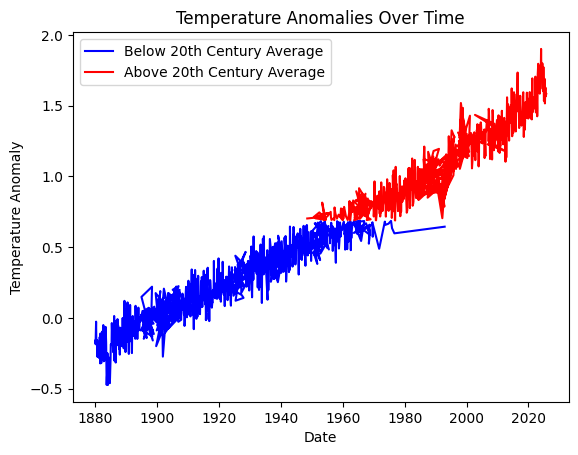

In [325]:
twen_cent = (df['DT'] < '2001') & (df['DT'] >= '1901')
twen_cent_avg = np.mean(twen_cent)
blw_avg = df[df['Temps']< twen_cent_avg] 
abv_avg = df[df['Temps'] >= twen_cent_avg]
plt.plot(blw_avg['DT'], blw_avg['Temps'], label='Below 20th Century Average', color='blue')
plt.plot(abv_avg['DT'], abv_avg['Temps'], label='Above 20th Century Average', color='red')
plt.xlabel('Date')
plt.ylabel('Temperature Anomaly')
plt.title('Temperature Anomalies Over Time')
plt.legend()
plt.show()

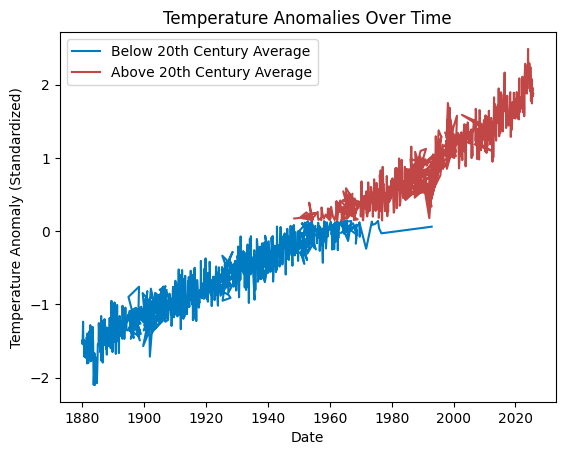

In [326]:
df['Temps_Std'] = (df['Temps'] - df['Temps'].mean()) / df['Temps'].std()
blw_avg = df[df['Temps']< twen_cent_avg] 
abv_avg = df[df['Temps'] >= twen_cent_avg]
plt.plot(blw_avg['DT'], blw_avg['Temps_Std'], label='Below 20th Century Average', color='#007AC0')
plt.plot(abv_avg['DT'], abv_avg['Temps_Std'], label='Above 20th Century Average', color='#C14747')
plt.xlabel('Date')
plt.ylabel('Temperature Anomaly (Standardized)')
plt.title('Temperature Anomalies Over Time')
plt.legend()
plt.show()

In [327]:
grouped_by_year = df.groupby(df['DT'].dt.year)['Temps'].mean()
top_5_years = grouped_by_year.sort_values(ascending=False).head(5)
top_5_years

DT
2024    1.737864
2023    1.720833
2025    1.583250
2016    1.549167
2022    1.527708
Name: Temps, dtype: float64